train shape: (42000, 785)
test shape: (28000, 784)
sample shape: (28000, 2)

train columns: ['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9', 'pixel10', 'pixel11', 'pixel12', 'pixel13', 'pixel14', 'pixel15', 'pixel16', 'pixel17', 'pixel18', 'pixel19', 'pixel20', 'pixel21', 'pixel22', 'pixel23', 'pixel24', 'pixel25', 'pixel26', 'pixel27', 'pixel28', 'pixel29', 'pixel30', 'pixel31', 'pixel32', 'pixel33', 'pixel34', 'pixel35', 'pixel36', 'pixel37', 'pixel38', 'pixel39', 'pixel40', 'pixel41', 'pixel42', 'pixel43', 'pixel44', 'pixel45', 'pixel46', 'pixel47', 'pixel48', 'pixel49', 'pixel50', 'pixel51', 'pixel52', 'pixel53', 'pixel54', 'pixel55', 'pixel56', 'pixel57', 'pixel58', 'pixel59', 'pixel60', 'pixel61', 'pixel62', 'pixel63', 'pixel64', 'pixel65', 'pixel66', 'pixel67', 'pixel68', 'pixel69', 'pixel70', 'pixel71', 'pixel72', 'pixel73', 'pixel74', 'pixel75', 'pixel76', 'pixel77', 'pixel78', 'pixel79', 'pixel80', 'pixel81', 'pixel

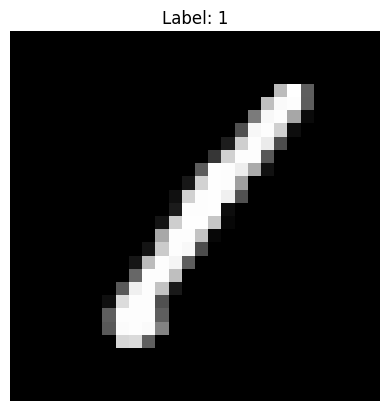

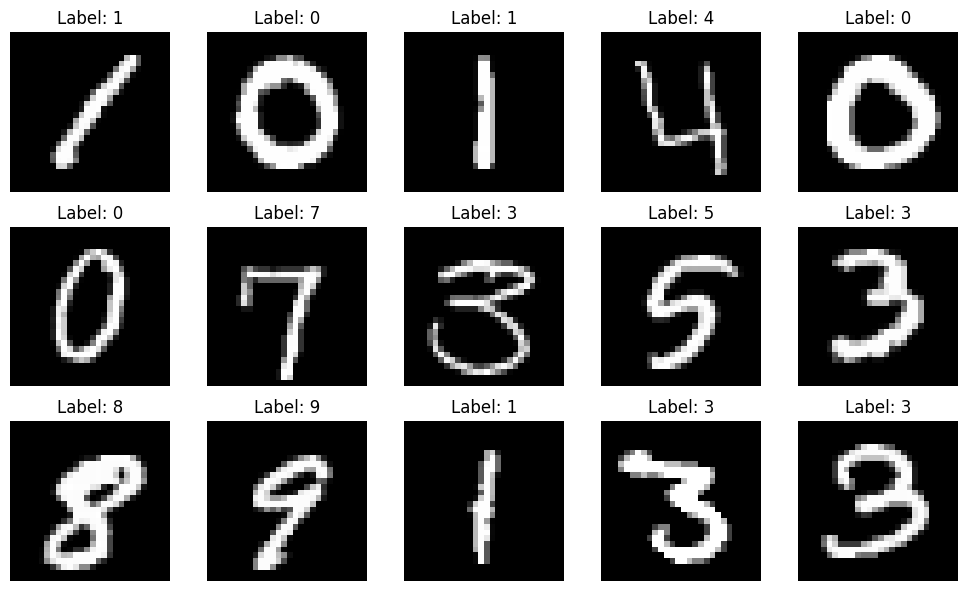

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# CSV読み込み
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

# --- 基本情報を確認 ---
print("train shape:", train.shape)
print("test shape:", test.shape)
print("sample shape:", sample.shape)
print("\ntrain columns:", train.columns.tolist())

# ラベルの分布確認
print("\nLabel value counts:")
print(train['label'].value_counts())

# --- 1枚目の画像を確認 ---
first_image = train.iloc[0, 1:].values.reshape(28, 28)
label = train.iloc[0, 0]

plt.imshow(first_image, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

# --- 複数の画像をグリッド表示 ---
fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    img = train.iloc[i, 1:].values.reshape(28, 28)
    label = train.iloc[i, 0]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()


In [2]:
from sklearn.model_selection import train_test_split
import numpy as np

# --- データ分割 ---
X = train.drop("label", axis=1).values
y = train["label"].values

# 画像サイズ: 28x28
X = X.reshape(-1, 28, 28, 1).astype("float32")
X_test = test.values.reshape(-1, 28, 28, 1).astype("float32")

# --- 正規化（0〜1にスケーリング） ---
X /= 255.0
X_test /= 255.0

# --- 訓練・検証データに分割 ---
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)


X_train: (33600, 28, 28, 1)
X_val: (8400, 28, 28, 1)
y_train: (33600,)
y_val: (8400,)


In [4]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.4/620.4 MB 44.4 MB/s  0:00:11m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 50.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 51.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 52.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 48.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 54.8 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23/23 [tensorflow]3 [tensorflow]-py]a-server]
